In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/AirPassengers.csv')

# Display the first 5 rows to understand the data structure
print("Original DataFrame head:")
display(df.head())

# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("\nDataFrame after setting Month as index:")
display(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Original DataFrame head:


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121



DataFrame after setting Month as index:


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121



Missing values:
#Passengers    0
dtype: int64


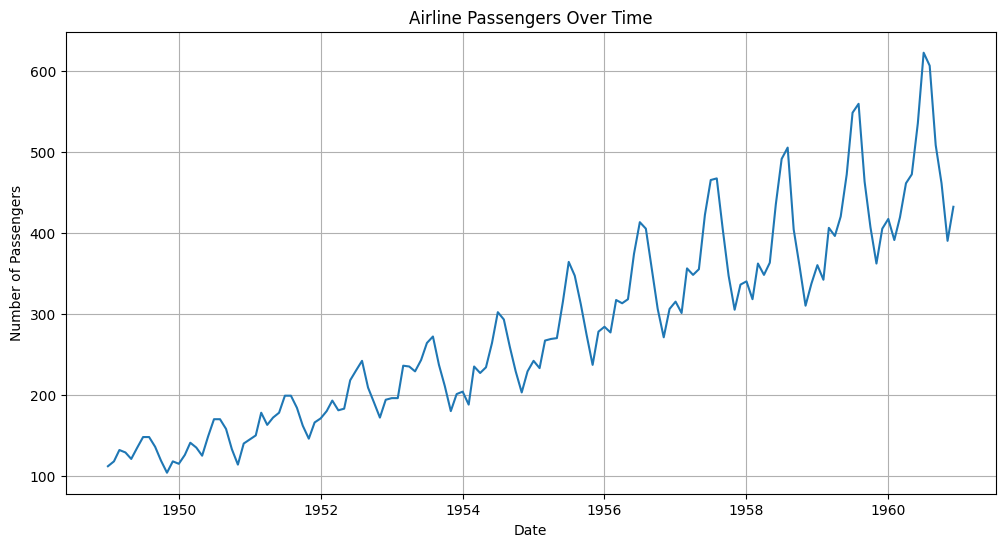

In [2]:
# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['#Passengers'])
plt.title('Airline Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Convert DataFrame to numpy array
data = df['#Passengers'].values.reshape(-1, 1)

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Function to create sequences for RNN
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Define sequence length
sequence_length = 12 # Using 12 months data to predict the next month

# Create sequences
X, y = create_sequences(data_scaled, sequence_length)

# Split data into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (105, 12, 1)
Shape of y_train: (105, 1)
Shape of X_test: (27, 12, 1)
Shape of y_test: (27, 1)


In [4]:
import torch
import torch.nn as nn

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()
X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).float()

# Define the RNN model
class AirPassengersRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(AirPassengersRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Pass through LSTM layer
        out, _ = self.lstm(x, (h0, c0))

        # Get the output of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Hyperparameters for the model
input_size = 1
hidden_size = 50
num_layers = 1
output_size = 1

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate the model
model = AirPassengersRNN(input_size, hidden_size, num_layers, output_size).to(device)

print(model)

AirPassengersRNN(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [5]:
import torch.optim as optim

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
num_epochs = 100
train_losses = []

model.train() # Set the model to training mode
for epoch in range(num_epochs):
    # Move data to device
    X_train_t_device = X_train_t.to(device)
    y_train_t_device = y_train_t.to(device)

    # Forward pass
    outputs = model(X_train_t_device)
    loss = criterion(outputs, y_train_t_device)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training complete.")

Epoch [10/100], Loss: 0.1121
Epoch [20/100], Loss: 0.0411
Epoch [30/100], Loss: 0.0297
Epoch [40/100], Loss: 0.0209
Epoch [50/100], Loss: 0.0201
Epoch [60/100], Loss: 0.0177
Epoch [70/100], Loss: 0.0154
Epoch [80/100], Loss: 0.0129
Epoch [90/100], Loss: 0.0100
Epoch [100/100], Loss: 0.0075
Training complete.


Test RMSE: 80.5946


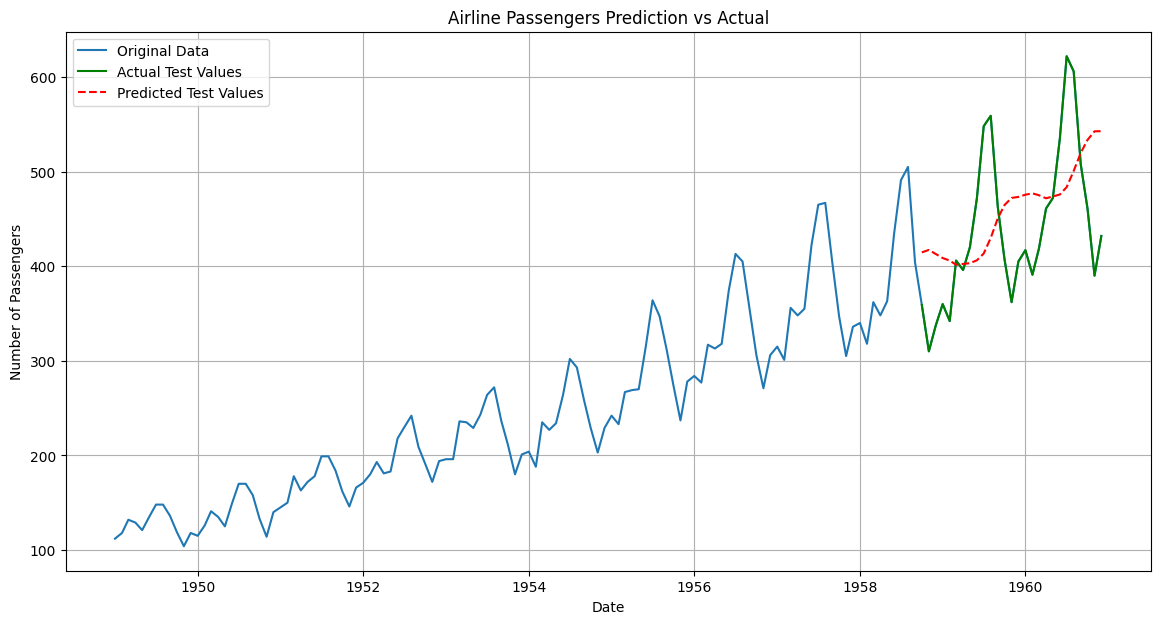

In [6]:
from sklearn.metrics import mean_squared_error

model.eval() # Set the model to evaluation mode
with torch.no_grad():
    X_test_t_device = X_test_t.to(device)
    test_predictions_scaled = model(X_test_t_device)

# Convert predictions and actual values back to original scale
test_predictions = scaler.inverse_transform(test_predictions_scaled.cpu().numpy())
y_test_actual = scaler.inverse_transform(y_test_t.cpu().numpy())

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
print(f"Test RMSE: {rmse:.4f}")

# Plot the results
plt.figure(figsize=(14, 7))

# Plot original data (up to the point where test data begins)
# The index for plotting needs to be handled carefully because of sequence creation.
# The actual values of y_train correspond to the points immediately following the training sequences.
# The actual values of y_test correspond to the points immediately following the test sequences.

# We need to reconstruct the full time series indices for plotting.
# The original DataFrame index is df.index
# The number of data points used to create X is len(data_scaled) - sequence_length
# The training data covers the first train_size points of X and y
# The test data covers the remaining points of X and y

# Adjusting indices for plotting
train_plot_index = df.index[sequence_length : sequence_length + train_size]
test_plot_index = df.index[sequence_length + train_size : sequence_length + train_size + len(y_test_actual)]

plt.plot(df.index, scaler.inverse_transform(data_scaled), label='Original Data')
plt.plot(test_plot_index, y_test_actual, label='Actual Test Values', color='green')
plt.plot(test_plot_index, test_predictions, label='Predicted Test Values', color='red', linestyle='--')

plt.title('Airline Passengers Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()